# Wine Quality Prediction 
---

### 1.Objective
---
To predict wine quality based on physicochemical properties using
Random Forest, SGD Classifier, and Support Vector Classifier (SVC).



---
### 2.Import Libraries
---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

---
### 3.Load dataset
---

In [2]:
df = pd.read_csv("winequality-red.csv", sep=';')

---
### 4.Understand Dataset
---

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

---
### 5.Check missing values
---

In [8]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(240)

---
### 6.Understand the target variable
---

In [10]:
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

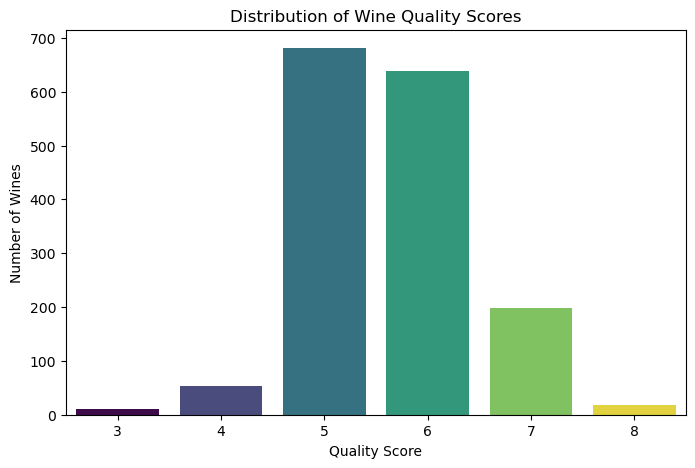

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='quality',
    hue='quality',
    palette='viridis',
    legend=False
)

plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')
plt.show()

### Class Imbalance

The distribution of wine quality scores is not uniform. Some quality
categories contain considerably more observations than others, while
very low and very high quality wines are less represented.

This imbalance can affect classification because a model may become
biased toward the majority class. Therefore, accuracy alone may not
provide a complete picture of model performance. Precision, recall,
F1-score, and the confusion matrix are also considered.

---
### 7.EDA: Distribution of chemical features
---

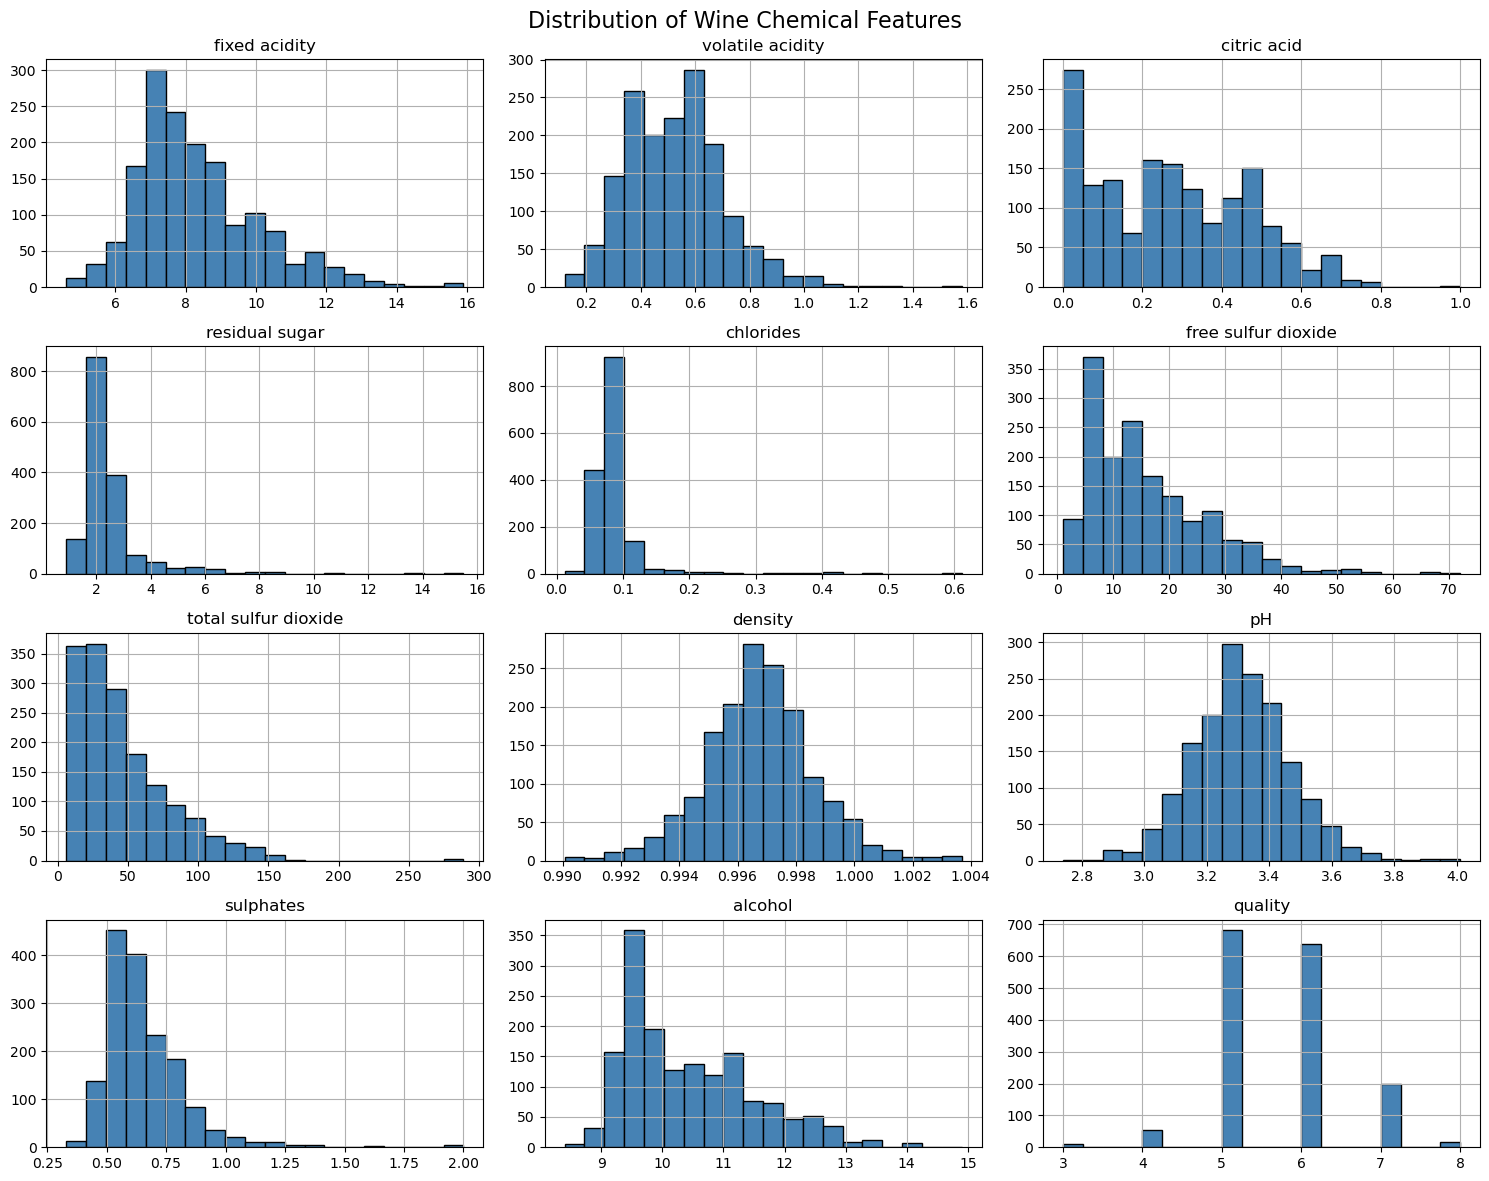

In [12]:
df.hist(
    figsize=(15, 12),
    bins=20,
    color='steelblue',
    edgecolor='black'
)

plt.suptitle('Distribution of Wine Chemical Features', fontsize=16)
plt.tight_layout()
plt.show()

---
### 8.Correlation heatmap
---

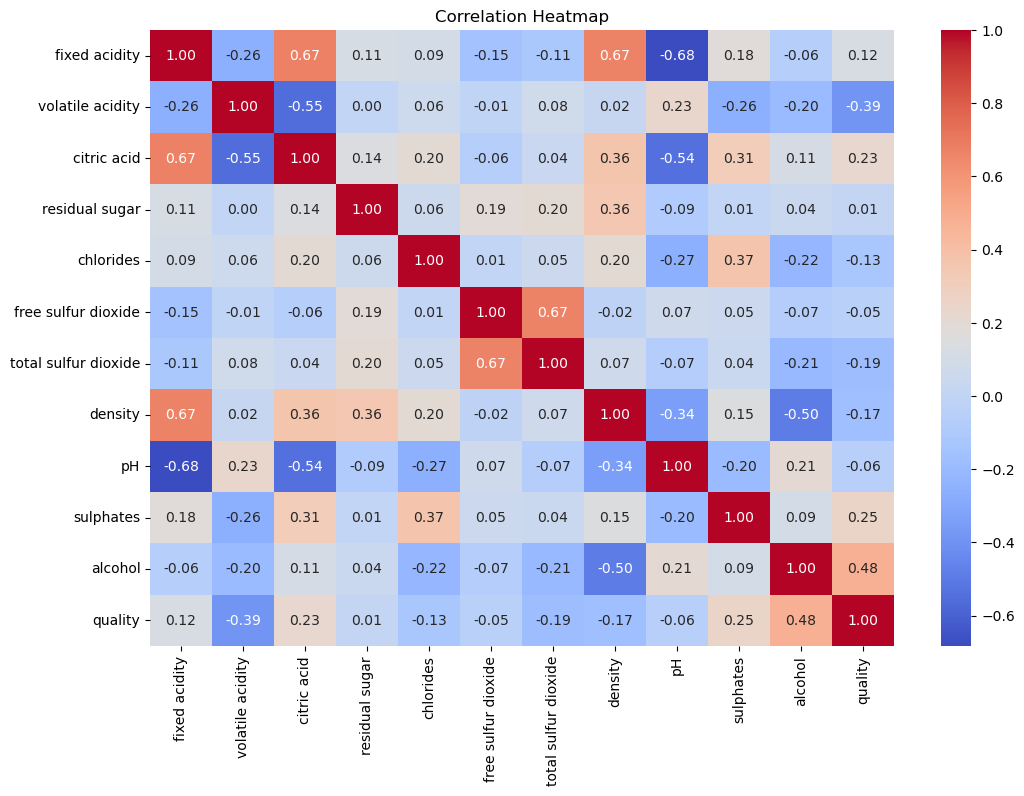

In [13]:
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

---
### 9.Feature engineering
---

In [14]:
df['quality_label'] = df['quality'].apply(
    lambda x: 1 if x >= 6 else 0
)

In [15]:
df['quality_label'].value_counts()

quality_label
1    855
0    744
Name: count, dtype: int64

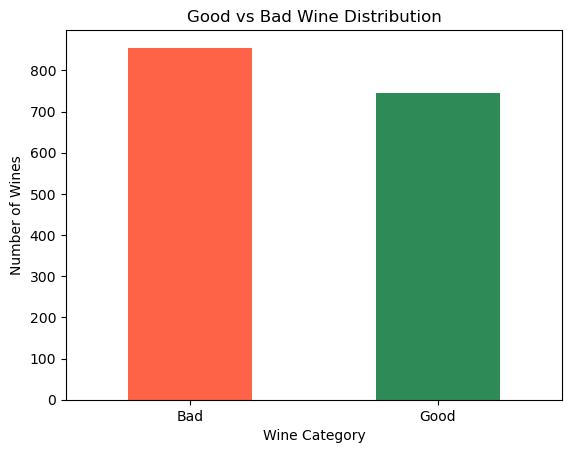

In [16]:
df['quality_label'].value_counts().plot(
    kind='bar',
    color=['tomato', 'seagreen']
)

plt.title('Good vs Bad Wine Distribution')
plt.xlabel('Wine Category')
plt.ylabel('Number of Wines')
plt.xticks(
    ticks=[0, 1],
    labels=['Bad', 'Good'],
    rotation=0
)

plt.show()

### Feature Engineering

The original quality score is an ordinal score with several classes,
but the distribution is imbalanced, particularly for the extreme
quality scores.

For this classification task, the quality score was converted into a
binary target:

- Quality < 6 → Bad Wine
- Quality >= 6 → Good Wine

This transformation reduces the effect of severely underrepresented
quality categories and creates a simpler classification problem.

Binary classification is also easier to interpret for a practical
deployment scenario where the objective is to identify whether a wine
meets a minimum quality threshold.


In [17]:
X = df.drop(['quality', 'quality_label'], axis=1)

y = df['quality_label']

In [18]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [19]:
y.head()

0    0
1    0
2    0
3    1
4    0
Name: quality_label, dtype: int64

---
### 10.Train/test split
---

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
stratify=y

In [22]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1279, 11)
Testing set: (320, 11)


---
### 11.Feature scaling
---

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [24]:
scaler.fit_transform(X_train)

array([[-0.59096646, -0.08898536, -0.47926523, ...,  1.3506617 ,
         0.43263109, -0.8741677 ],
       [-0.93251464,  0.07896192, -0.73734044, ...,  1.93541674,
        -0.11163301, -0.5942794 ],
       [ 0.43367806, -0.14496778,  0.14011526, ...,  0.05120607,
         0.31168351,  0.05879332],
       ...,
       [-0.64789116,  0.75075102, -1.25349085, ...,  1.41563448,
        -0.53494953, -0.6875755 ],
       [-1.27406281,  1.00267194, -0.89218556, ...,  1.87044395,
         0.00931457, -0.22109499],
       [ 0.83215092, -0.08898536, -0.42765019, ..., -0.53354896,
        -0.47447574,  0.05879332]])

In [25]:
scaler.transform(X_test)

array([[-0.02171951,  0.4708389 ,  0.14011526, ...,  0.57098832,
        -0.29305437, -0.22109499],
       [-0.1924936 ,  0.63878617, -0.27280506, ...,  0.37606998,
        -0.47447574,  0.52527383],
       [-0.24941829,  2.01035559, -1.25349085, ...,  0.3110972 ,
        -1.98632046, -1.24735211],
       ...,
       [-0.70481585,  0.86271587, -1.40833597, ...,  0.89585223,
        -0.77684468, -0.8741677 ],
       [ 0.88907562,  0.58280375, -0.16957498, ..., -1.44316791,
        -0.53494953, -0.96746381],
       [-0.0786442 ,  0.97468072, -0.22119002, ..., -0.79344009,
         0.25120973, -0.96746381]])

---
### 12.Random Forest
---

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [27]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [28]:
rf_pred = rf_model.predict(X_test)

In [29]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.815625


In [30]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=['Bad', 'Good']
))

              precision    recall  f1-score   support

         Bad       0.79      0.82      0.81       149
        Good       0.84      0.81      0.82       171

    accuracy                           0.82       320
   macro avg       0.81      0.82      0.82       320
weighted avg       0.82      0.82      0.82       320



In [31]:
X_train
X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
100,8.3,0.610,0.30,2.1,0.084,11.0,50.0,0.99720,3.40,0.61,10.2
1391,8.0,0.640,0.22,2.4,0.094,5.0,33.0,0.99612,3.37,0.58,11.0
170,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.1
461,8.3,0.615,0.22,2.6,0.087,6.0,19.0,0.99820,3.26,0.61,9.3
346,6.6,0.815,0.02,2.7,0.072,17.0,34.0,0.99550,3.58,0.89,12.3
...,...,...,...,...,...,...,...,...,...,...,...
859,6.8,0.560,0.22,1.8,0.074,15.0,24.0,0.99438,3.40,0.82,11.2
741,9.2,0.530,0.24,2.6,0.078,28.0,139.0,0.99788,3.21,0.57,9.5
1550,7.1,0.680,0.00,2.3,0.087,17.0,26.0,0.99783,3.45,0.53,9.5
536,9.9,0.630,0.24,2.4,0.077,6.0,33.0,0.99740,3.09,0.57,9.4


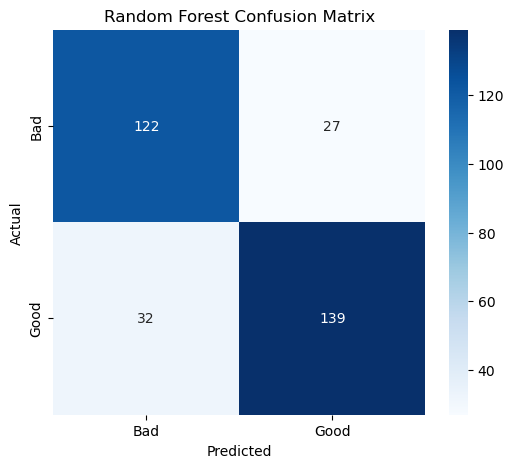

In [32]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

---
### 13.SGD Classifier
---

In [33]:
sgd_model = SGDClassifier(
    loss='hinge',
    max_iter=1000,
    random_state=42
)

In [34]:
sgd_model.fit(X_train_scaled, y_train)

SGDClassifier(random_state=42)

In [35]:
sgd_pred = sgd_model.predict(X_test_scaled)

In [36]:
sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", sgd_accuracy)

SGD Accuracy: 0.65625


In [37]:
print(classification_report(
    y_test,
    sgd_pred,
    target_names=['Bad', 'Good']
))

              precision    recall  f1-score   support

         Bad       0.65      0.56      0.60       149
        Good       0.66      0.74      0.70       171

    accuracy                           0.66       320
   macro avg       0.66      0.65      0.65       320
weighted avg       0.66      0.66      0.65       320



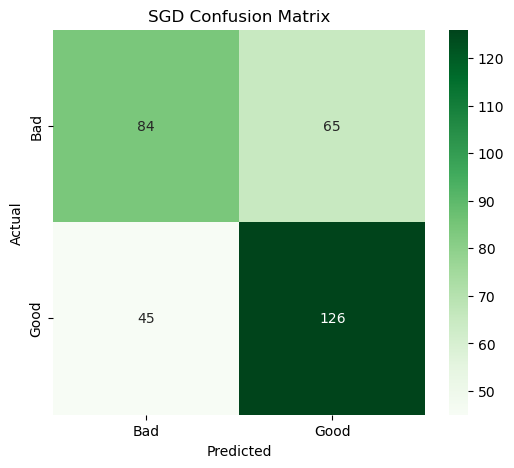

In [38]:
cm_sgd = confusion_matrix(y_test, sgd_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SGD Confusion Matrix')

plt.show()

---
### 14.SVC
---

In [39]:
svc_model = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

In [40]:
svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [41]:
svc_pred = svc_model.predict(X_test_scaled)

In [42]:
svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", svc_accuracy)

SVC Accuracy: 0.7625


In [43]:
print(classification_report(
    y_test,
    svc_pred,
    target_names=['Bad', 'Good']
))

              precision    recall  f1-score   support

         Bad       0.72      0.81      0.76       149
        Good       0.81      0.72      0.76       171

    accuracy                           0.76       320
   macro avg       0.77      0.77      0.76       320
weighted avg       0.77      0.76      0.76       320



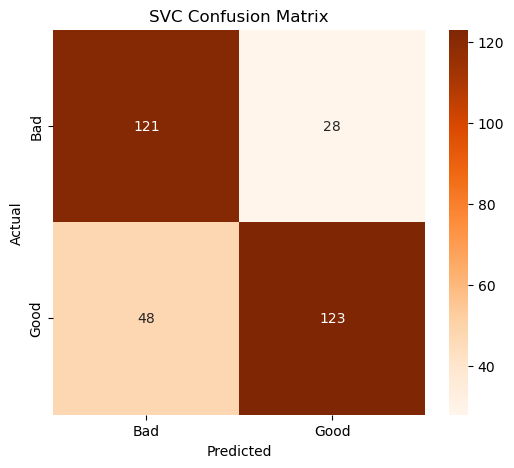

In [44]:
cm_svc = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVC Confusion Matrix')

plt.show()

---
### 15.Comparing all the 3 models
---

In [45]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD Classifier',
        'SVC'
    ],
    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.815625
1,SGD Classifier,0.656250
2,SVC,0.762500


In [46]:
comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

comparison

,Model,Accuracy
0,Random Forest,0.815625
2,SVC,0.762500
1,SGD Classifier,0.656250


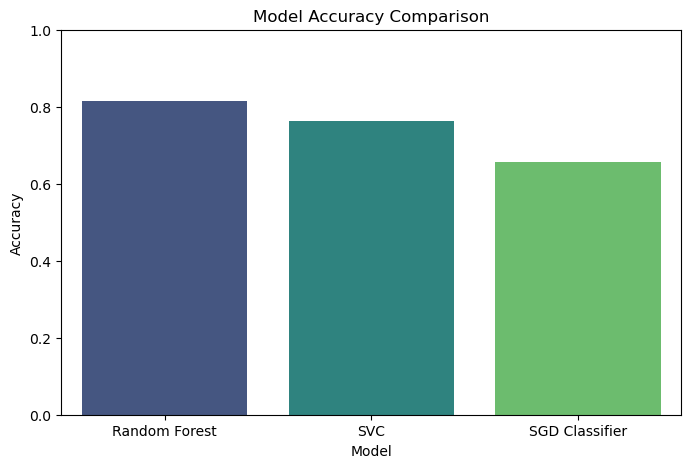

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy',
    hue='Model',
    palette='viridis',
    legend=False
)

plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')

plt.show()

---
### 16.Random Forest feature importance
---

In [48]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.178138
9,sulphates,0.138765
1,volatile acidity,0.113982
6,total sulfur dioxide,0.098226
7,density,0.090872
4,chlorides,0.070574
0,fixed acidity,0.068242
8,pH,0.066011
2,citric acid,0.061240
5,free sulfur dioxide,0.058907


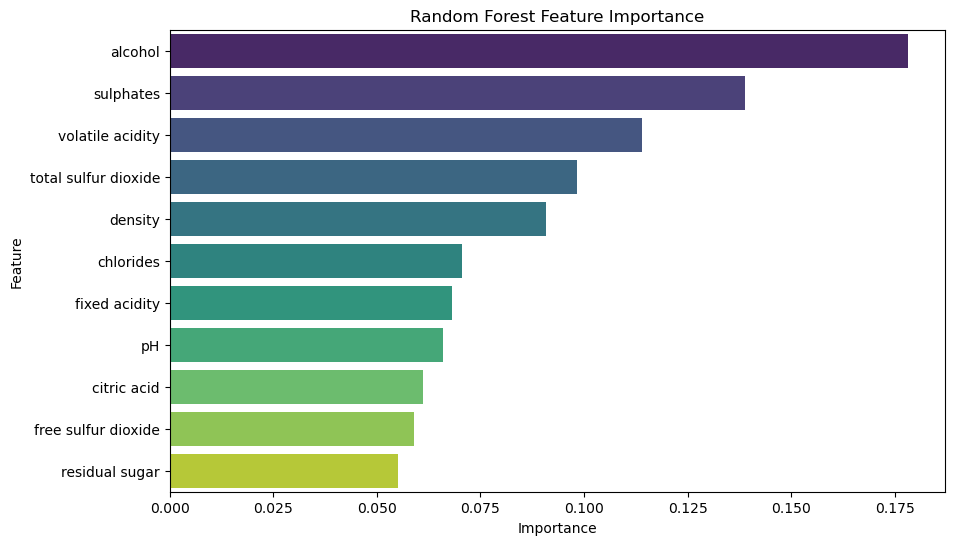

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

---
### 17.Conclusion
---

Three classification models — Random Forest, SVC, and SGD Classifier — were trained and evaluated for predicting wine quality.

The models achieved the following accuracy scores:

| Model | Accuracy |
|---|---:|
| **Random Forest** | **81.56%** |
| **SVC** | **76.25%** |
| **SGD Classifier** | **65.63%** |

#### Model Performance :

- **Random Forest** achieved the highest accuracy of **81.56%**, making it the best-performing model among the three.
- **SVC** achieved an accuracy of **76.25%**, showing reasonably good performance but performing lower than Random Forest.
- **SGD Classifier** achieved **65.63%**, which was the lowest accuracy of the three models.


Based on the accuracy results, **Random Forest is the most suitable model for this wine quality classification task**. It achieved the highest predictive accuracy and can also provide feature importance, which helps identify the physicochemical properties that contribute most to the model's predictions.

Therefore, **Random Forest would be the preferred model for deployment** among the three evaluated models.

#### Final Ranking :

1. 🥇 **Random Forest — 81.56%**
2. 🥈 **SVC — 76.25%**
3. 🥉 **SGD Classifier — 65.63%**

**Overall, Random Forest demonstrated the best performance and is recommended as the final model for this project.**